In [7]:
## Load full joint library + precomputed gradient-corrected deepSHAP attributions.
import os, sys, numpy as np, pandas as pd

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap, ENHANCER_LEN

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n_full][keep]

print(f'{len(df)} seqs   X={tuple(em.X.shape)}')


EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs   X=(56975, 4, 281)


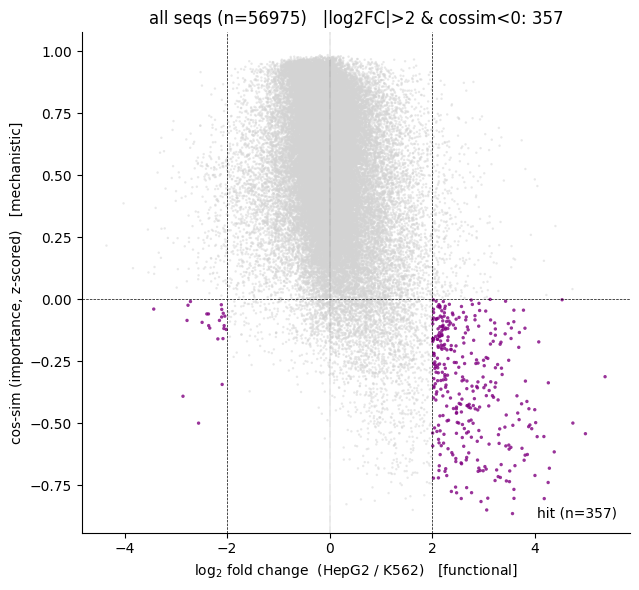

In [8]:
## 2d (functional, mechanistic) space — all seqs.
##   x = log2 fold change HepG2 / K562 (volcano-style axis, linear)
##   y = cos-sim of importance maps (mechanistic; low = divergent across cell lines)
import matplotlib.pyplot as plt

# --- knobs ---
LFC_CUT    = 2.0   # |log2FC| > LFC_CUT either direction = functional hit (2.0 = 4x)
COSSIM_CUT = 0.0   # cossim < COSSIM_CUT = mechanistically divergent
# -------------

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values
fin = np.isfinite(cossim) & np.isfinite(lfc)

func = np.abs(lfc) > LFC_CUT
mech = cossim < COSSIM_CUT
sel  = fin & func & mech

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(lfc[fin & ~sel], cossim[fin & ~sel], s=3, c='lightgray',
           alpha=0.5, edgecolors='none', rasterized=True)
ax.scatter(lfc[sel], cossim[sel], s=6, c='purple',
           alpha=0.8, edgecolors='none', label=f'hit (n={sel.sum()})')
ax.axhline(COSSIM_CUT, color='k', lw=0.5, ls='--')
ax.axvline( LFC_CUT,   color='k', lw=0.5, ls='--')
ax.axvline(-LFC_CUT,   color='k', lw=0.5, ls='--')
ax.axvline(0, color='k', lw=0.3, ls=':')
ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
ax.set_title(f'all seqs (n={fin.sum()})   |log2FC|>{LFC_CUT:g} & cossim<{COSSIM_CUT:g}: {sel.sum()}')
ax.legend(frameon=False, loc='lower right')
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


In [6]:
## Load TF-MoDISco results for the full ~56K library (run separately via run_modisco_full.sbatch).
import h5py
from types import SimpleNamespace

ENH = ENHANCER_LEN
OUT_DIR = os.path.join(REPO, 'genomic_targets/data/modisco')
HP_TAG = f'full56k_enh{ENH}_default'

def load_patterns(h5_path, group):
    out = []
    with h5py.File(h5_path, 'r') as f:
        if group not in f: return []
        names = sorted(f[group].keys(), key=lambda s: int(s.split('_')[-1]))
        for nm in names:
            g = f[group][nm]
            seqlets = [SimpleNamespace(example_idx=int(e))
                       for e in g['seqlets']['example_idx'][...]]
            out.append(SimpleNamespace(
                contrib_scores=g['contrib_scores'][...],
                seqlets=seqlets,
            ))
    return out

results_full = {}
for ct in CT:
    h5 = os.path.join(OUT_DIR, f'{ct}_{HP_TAG}.h5')
    pos = load_patterns(h5, 'pos_patterns')
    neg = load_patterns(h5, 'neg_patterns')
    results_full[ct] = (pos, neg, h5)
    print(f'{ct:5s}  pos={len(pos)} neg={len(neg)}  -> {os.path.basename(h5)}')


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/modisco/K562_full56k_enh230_default.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)